# 6 · Robust Portfolio Optimization: Black-Litterman and Ledoit-Wolf

*Module 2 — Portfolio Construction*

Two of the most widely used fixes, in practice, for the instability Notebook 5 diagnosed: one tames the covariance matrix, the other tames expected returns.

## 1. Motivation

Notebook 5 left us with a genuine dilemma. Mean-variance optimization is theoretically elegant but practically unstable, and the instability gets *worse*, not better, the more inputs (assets, history) you throw at it — precisely because $\hat\mu$ is so hard to pin down and $\hat\Sigma$ becomes ill-conditioned. Two techniques, both now industry standard — Ledoit-Wolf shrinkage (used throughout quantitative asset management) and Black-Litterman (developed at Goldman Sachs and used by asset managers worldwide) — do not abandon optimization. Instead, they change *what* gets fed into it.

## 2. Intuition

**Ledoit-Wolf shrinkage** does something you may already know from statistics under a different name: rather than trusting a noisy sample estimate completely, blend it with a simple, stable "prior" guess. If the sample covariance matrix is a shaky, high-variance estimate (especially with many assets and limited history), and a simple structured matrix — say, "every asset has the same variance, zero correlation" — is a biased but very *low*-variance guess, then a weighted average of the two can have lower total error than either extreme. This is the classical statistical bias-variance trade-off (the same idea behind James-Stein shrinkage), applied to a covariance matrix instead of a mean.

**Black-Litterman** attacks the harder problem directly: instead of asking you to specify a full vector of expected returns for every asset (Notebook 5 showed how badly sample means do this), start from the returns *implied by the market itself*. If the market portfolio reflects the collective judgment of every investor, we can mathematically reverse-engineer what expected returns would have to be for the market portfolio to be the optimal one to hold. Then — and only then — let the investor blend in a *few* specific, genuinely-held views ("I think Galp will outperform"), with everything the investor has no opinion about pulled sensibly back toward that market-implied equilibrium, rather than left to the whims of a noisy sample mean.

## 3. Theory

### 3.1 Ledoit-Wolf shrinkage

A shrinkage estimator blends the sample covariance $\hat\Sigma$ with a structured target $F$:

$$
\hat\Sigma_{shrink} = \delta F + (1-\delta)\hat\Sigma, \qquad \delta \in [0,1].
$$

To see *why* a good $\delta$ exists, consider a single entry $\sigma_{ij}$, with sample estimate $\hat\sigma_{ij}$ (unbiased, variance $v_{ij}$) and a fixed target value $f_{ij}$ with bias $b_{ij} = f_{ij}-\sigma_{ij}$. The shrunk estimate is $\tilde\sigma_{ij} = \delta f_{ij} + (1-\delta)\hat\sigma_{ij}$, and its mean squared error decomposes as

$$
MSE(\delta) = \mathbb E\big[(\tilde\sigma_{ij}-\sigma_{ij})^2\big] = \delta^2 b_{ij}^2 + (1-\delta)^2 v_{ij}
$$

(treating the target as fixed, so the cross term vanishes). Minimizing over $\delta$: $\frac{d}{d\delta}MSE = 2\delta b_{ij}^2 - 2(1-\delta)v_{ij} = 0 \Rightarrow \delta(b_{ij}^2+v_{ij}) = v_{ij}$, giving

$$
\boxed{\;\delta^\ast = \frac{v_{ij}}{v_{ij}+b_{ij}^2}\;}
$$

— shrink more when the sample estimate is noisier ($v_{ij}$ large) relative to how wrong the target is ($b_{ij}^2$ small). Ledoit and Wolf (2004, *A Well-Conditioned Estimator for Large-Dimensional Covariance Matrices*, Journal of Multivariate Analysis) formalize exactly this logic across the *whole* covariance matrix at once (aggregating the analogue of $v_{ij}$ and $b_{ij}$ over every entry, using the data itself to estimate both), and derive a single optimal shrinkage intensity $\delta^\ast$ in closed form. Their target — and the one implemented in `sklearn.covariance.LedoitWolf`, which we use below — is a **scaled identity matrix**, $F = \bar\sigma^2 I$ where $\bar\sigma^2 = \mathrm{trace}(\hat\Sigma)/n$ is the average sample variance: "every asset has the same variance, and zero correlation with every other asset" is the simple, low-variance prior being blended in.

### 3.2 Black-Litterman

**Step 1: reverse-engineer equilibrium returns.** Suppose a representative investor with risk-aversion $\lambda$ chooses $w$ to maximize $w^\top\mu - \frac{\lambda}{2}w^\top\Sigma w$. The first-order condition is $\mu - \lambda\Sigma w = 0$. If the market-cap-weighted portfolio $w_{mkt}$ is the one such an investor would hold, then $\mu$ must equal

$$
\Pi = \lambda\,\Sigma\, w_{mkt} ,
$$

the **implied equilibrium return** vector — no subjective forecast needed, just $\Sigma$, observed market weights, and a risk-aversion constant (often calibrated as $\lambda = (\mathbb E[R_m]-r_f)/\sigma_m^2$, the market's own reward-to-variance ratio).

**Step 2: blend in views, Bayesian-style.** The cleanest way to see the mechanics is the simplest possible case: a Gaussian prior $\mu \sim \mathcal N(m_0,\sigma_0^2)$, combined with a single noisy observation $y = \mu+\varepsilon$, $\varepsilon\sim\mathcal N(0,\sigma_\varepsilon^2)$. Standard conjugate-Gaussian Bayesian updating gives the posterior

$$
\mu \mid y \;\sim\; \mathcal N\!\left(\frac{\sigma_\varepsilon^2\, m_0 + \sigma_0^2\, y}{\sigma_0^2+\sigma_\varepsilon^2},\;\; \left(\frac{1}{\sigma_0^2}+\frac{1}{\sigma_\varepsilon^2}\right)^{-1}\right) ,
$$

a **precision-weighted average**: the posterior mean weights the prior and the observation by how confident we are in each (inverse variance = precision), and posterior precision is simply the sum of the two precisions. Black-Litterman is the direct multivariate generalization of exactly this idea. The "prior" is $\Pi$ with covariance $\tau\Sigma$ (where $\tau$ is a small constant, e.g. 0.025-0.05, reflecting our uncertainty about the equilibrium estimate itself — not to be confused with $\Sigma$, the returns covariance). The "observation" is a set of $k$ investor views, written as $P\mu = Q + \varepsilon$, $\varepsilon\sim\mathcal N(0,\Omega)$, where each row of the **pick matrix** $P$ selects or combines the assets involved in one view, $Q$ holds the view's stated return, and $\Omega$ (usually diagonal) encodes how confident the investor is in each view. The multivariate precision-weighted combination is the Black-Litterman master formula:

$$
\boxed{\; \mathbb E[\mu\mid\text{views}] = \Big[(\tau\Sigma)^{-1} + P^\top\Omega^{-1}P\Big]^{-1}\Big[(\tau\Sigma)^{-1}\Pi + P^\top\Omega^{-1}Q\Big] \;}
$$

Where the investor has no view at all, $P$ has no corresponding row, and the formula leaves $\Pi$ essentially untouched for those assets — this is precisely why Black-Litterman portfolios look like the market, tilted only where the investor actually has something to say.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(42)

## 4. Implementation

### 4.1 The same universe as Notebook 5

We reuse the identical 8-asset universe and its "true" parameters, so results here are directly comparable to what you saw there.

In [2]:
TICKERS = ['GALP', 'EDP', 'JMT', 'BCP', 'NOS', 'SEM', 'SPY', 'IEF']
N = len(TICKERS)
TRUE_ANN_VOL = np.array([0.26, 0.24, 0.22, 0.28, 0.30, 0.32, 0.16, 0.06])
TRUE_ANN_MU  = np.array([0.090, 0.080, 0.075, 0.070, 0.065, 0.060, 0.080, 0.030])

corr = np.eye(N)
for i in range(6):
    for j in range(6):
        if i != j:
            corr[i, j] = 0.45
for i in range(6):
    corr[i, 6] = corr[6, i] = 0.30
    corr[i, 7] = corr[7, i] = -0.05
corr[6, 7] = corr[7, 6] = -0.10
TRUE_SIGMA = np.diag(TRUE_ANN_VOL) @ corr @ np.diag(TRUE_ANN_VOL)

def gmv_weights(Sigma):
    v = np.linalg.solve(Sigma, np.ones(Sigma.shape[0]))
    return v / v.sum()

def tangency_weights(mu, Sigma, rf=0.0):
    e = mu - rf
    v = np.linalg.solve(Sigma, e)
    return v / v.sum()

def simulate_returns(mu_ann, Sigma_ann, T, seed):
    local_rng = np.random.default_rng(seed)
    return local_rng.multivariate_normal(mu_ann/252, Sigma_ann/252, size=T)

### 4.2 Does Ledoit-Wolf shrinkage actually reduce GMV instability?

We repeat Notebook 5's bootstrap experiment exactly, but this time shrink each resampled covariance matrix with `LedoitWolf` before computing GMV weights.

In [3]:
def bootstrap_gmv(T, n_boot, seed, use_shrinkage):
    local_rng = np.random.default_rng(seed)
    all_weights = np.zeros((n_boot, N))
    shrinkage_intensities = []
    for b in range(n_boot):
        X = simulate_returns(TRUE_ANN_MU, TRUE_SIGMA, T, seed=local_rng.integers(1, 10**9))
        if use_shrinkage:
            lw = LedoitWolf().fit(X)
            Sigma_hat = lw.covariance_ * 252
            shrinkage_intensities.append(lw.shrinkage_)
        else:
            Sigma_hat = np.cov(X, rowvar=False) * 252
        all_weights[b] = gmv_weights(Sigma_hat)
    return all_weights, shrinkage_intensities

gmv_boot_sample, _ = bootstrap_gmv(T=252, n_boot=200, seed=1, use_shrinkage=False)
gmv_boot_lw, shrink_intensities = bootstrap_gmv(T=252, n_boot=200, seed=1, use_shrinkage=True)

print(f"Average LedoitWolf shrinkage intensity at T=252: {np.mean(shrink_intensities):.3f}")
print(f"\nAverage weight std. dev. across assets:")
print(f"  Raw sample covariance:      {gmv_boot_sample.std(axis=0).mean():.4f}")
print(f"  Ledoit-Wolf shrunk:         {gmv_boot_lw.std(axis=0).mean():.4f}")

Average LedoitWolf shrinkage intensity at T=252: 0.028

Average weight std. dev. across assets:
  Raw sample covariance:      0.0173
  Ledoit-Wolf shrunk:         0.0167


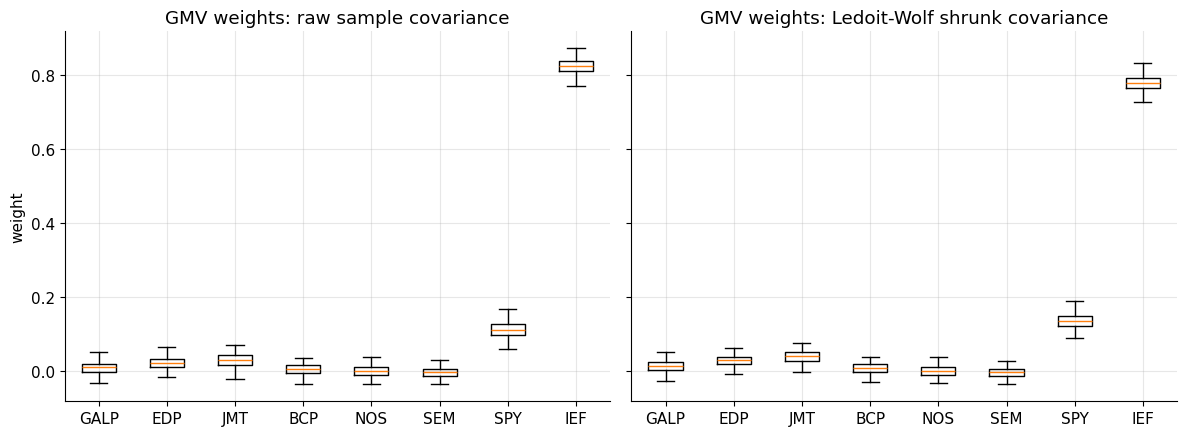

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].boxplot(gmv_boot_sample, tick_labels=TICKERS, showfliers=False)
axes[0].set_title('GMV weights: raw sample covariance')
axes[0].set_ylabel('weight')
axes[1].boxplot(gmv_boot_lw, tick_labels=TICKERS, showfliers=False)
axes[1].set_title('GMV weights: Ledoit-Wolf shrunk covariance')
plt.tight_layout()
plt.show()

### 4.3 Black-Litterman, implemented from scratch

We apply this to the six PSI-20 names alone (dropping SPY and IEF, which would otherwise dominate any real market-cap weighting and are not needed to illustrate the mechanics). We use illustrative, approximate relative sizes as $w_{mkt}$ — for a real deployment, these would come from actual free-float market capitalizations.

In [5]:
psi_tickers = ['GALP', 'EDP', 'JMT', 'BCP', 'NOS', 'SEM']
idx = [TICKERS.index(t) for t in psi_tickers]
Sigma6 = TRUE_SIGMA[np.ix_(idx, idx)]

w_mkt = np.array([0.25, 0.25, 0.20, 0.15, 0.10, 0.05])   # illustrative relative sizes, sum to 1
lam = 2.5                                                  # illustrative risk-aversion coefficient
tau = 0.04                                                  # standard small value: uncertainty about equilibrium

Pi = lam * Sigma6 @ w_mkt   # Step 1: implied equilibrium returns, Section 3.2
print("Implied equilibrium (annualized) returns:")
print(pd.Series(Pi, index=psi_tickers).round(4))

Implied equilibrium (annualized) returns:
GALP    0.0984
EDP     0.0892
JMT     0.0769
BCP     0.0971
NOS     0.0991
SEM     0.0996
dtype: float64


In [6]:
def black_litterman(Pi, Sigma, tau, P, Q, Omega):
    """Direct implementation of the boxed master formula in Section 3.2."""
    tau_Sigma_inv = np.linalg.inv(tau * Sigma)
    Omega_inv = np.linalg.inv(Omega)
    A = tau_Sigma_inv + P.T @ Omega_inv @ P
    b = tau_Sigma_inv @ Pi + P.T @ Omega_inv @ Q
    return np.linalg.solve(A, b)

# One view: "Galp's annual expected return is 12%" (well above its ~9% equilibrium implied value)
P = np.array([[1, 0, 0, 0, 0, 0]], dtype=float)
Q = np.array([0.12])
Omega = np.array([[tau * Sigma6[0, 0]]])   # a standard, moderate-confidence choice: view variance = tau * asset variance

mu_bl = black_litterman(Pi, Sigma6, tau, P, Q, Omega)
print("Black-Litterman posterior expected returns (with the Galp view):")
print(pd.Series(mu_bl, index=psi_tickers).round(4))

Black-Litterman posterior expected returns (with the Galp view):
GALP    0.1092
EDP     0.0937
JMT     0.0810
BCP     0.1024
NOS     0.1047
SEM     0.1055
dtype: float64


## 5. Worked example: comparing three ways to build a portfolio

In [7]:
w_bl = tangency_weights(mu_bl, Sigma6, rf=0.02)

# A naive alternative: one noisy one-year sample of returns, sample mean plugged directly into tangency weights
X_noisy = simulate_returns(TRUE_ANN_MU[idx], Sigma6, T=252, seed=7)
mu_naive = X_noisy.mean(axis=0) * 252
w_naive = tangency_weights(mu_naive, Sigma6, rf=0.02)

comparison = pd.DataFrame({
    'Market-cap weights': w_mkt,
    'Black-Litterman (1 view on GALP)': w_bl,
    'Naive tangency (1yr sample mean)': w_naive,
}, index=psi_tickers)
comparison.round(3)

,Market-cap weights,Black-Litterman (1 view on GALP),Naive tangency (1yr sample mean)
GALP,0.25,0.328,-12.097
EDP,0.25,0.224,-1.790
JMT,0.20,0.127,4.589
BCP,0.15,0.152,8.044
NOS,0.10,0.108,6.952
SEM,0.05,0.060,-4.698


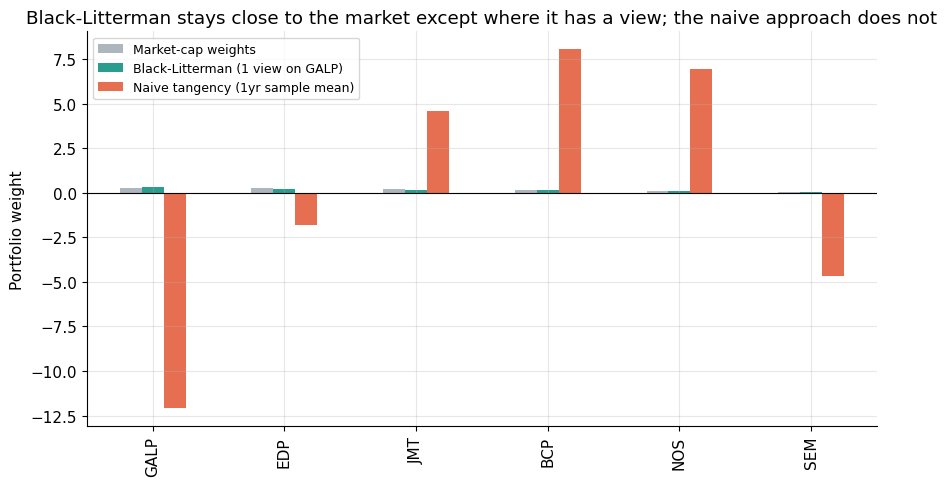

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison.plot(kind='bar', ax=ax, color=['#adb5bd', '#2a9d8f', '#e76f51'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Portfolio weight')
ax.set_title('Black-Litterman stays close to the market except where it has a view; the naive approach does not')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Interpreting the result

The Black-Litterman portfolio looks like the market portfolio with one deliberate, bounded tilt — more Galp, funded roughly proportionally from the rest — exactly matching what we told the model we believed. The naive tangency portfolio, built from a single noisy year of sample means (exactly like the unstable portfolios from Notebook 5), can allocate very differently, including large positions the investor never actually intended to bet on; it is simply chasing whichever asset happened to look best over one particular twelve-month sample. Black-Litterman did not make our GALP view "more true" — it simply stopped every *other* asset in the portfolio from being driven by noise we never meant to act on.

## 6. Limitations and pitfalls

- **The shrinkage target is still a choice.** A scaled-identity target is simple and well-studied, but it is not the only sensible option (a single-factor, CAPM-implied target is another classic choice from Ledoit and Wolf's own earlier work) — different targets shrink toward different "priors" about structure, and there is no free lunch that makes the choice disappear.
- **Black-Litterman needs a confidence, $\Omega$, for every view — and that is still a subjective judgment call.** A very confident but wrong view will pull the posterior a long way from equilibrium, just as it should mathematically; the model manages *how much* your views matter, not *whether* they are correct.
- **Reverse-optimization to get $\Pi$ assumes the market portfolio is mean-variance efficient** — essentially, that markets are efficient enough for cap-weighting to reflect a sensible collective judgment. This is a genuinely debated assumption in finance, not a settled fact, and different investors reasonably disagree about how much to trust it.
- **Neither technique eliminates estimation risk — they manage it.** Shrinkage still requires *some* estimate of the sample covariance to shrink; Black-Litterman still requires *someone's* views. Both are real improvements over the naive approach, not a free escape from the fundamental problem Notebook 5 described.

## 7. Exercises

**1. Shrinkage intensity vs. sample size.**
Using `bootstrap_gmv`, compute the average Ledoit-Wolf shrinkage intensity `lw.shrinkage_` at a few different sample sizes, e.g. $T \in \{60, 120, 252, 504, 1000\}$ (holding the number of assets fixed at 8). Plot shrinkage intensity against $T$. Does the pattern match the intuition from Notebook 5's $SE(\hat\mu)=\sigma/\sqrt T$ discussion — less data should mean a noisier sample estimate, and therefore more shrinkage?

**2. A second, more complex view.**
Add a *relative* second view to the Black-Litterman example: "Jerónimo Martins will outperform the equal-weighted average of BCP and NOS by 2% per year." (Hint: the corresponding row of $P$ has $+1$ on JMT and $-0.5$ on each of BCP and NOS.) Recompute `mu_bl` and `w_bl` with both views active. Then experiment with the view's confidence — make `Omega` for this new view much smaller (very confident) and then much larger (very unsure) — and describe how the resulting weights change.

**3. Combining both techniques.**
Modify the Black-Litterman pipeline so that the **Ledoit-Wolf shrunk** covariance matrix (rather than the true $\Sigma_6$) is used both inside the master formula and in the final tangency-weight step, based on one noisy simulated sample rather than the true covariance. Then re-run the Notebook 5-style rolling out-of-sample backtest (you will need to adapt `rolling_backtest` from that notebook) comparing: (a) naive sample-mean tangency, (b) Black-Litterman with shrunk covariance, and (c) equal-weight. Does combining the two techniques improve out-of-sample Sharpe or reduce turnover beyond what either technique achieves alone?